In [1]:
import requests
import pandas as pd 
import datetime as dt
import numpy as np
import plotly.express as px

In [189]:
import requests

headers = {
    'accept': '*/*',
    'Content-Type': 'application/json-patch+json',
}

data = '{\n  "source": "nwm",\n  "dateTimeSpan": {\n    "startDate": "01/01/2015 00:00:00",\n    "endDate": "12/31/2015 00:00:00",\n    "dateTimeFormat": "yyyy-MM-dd HH"\n  },\n  "geometry": {\n    "description": null,\n    "comID": 19121554,\n    "hucID": null,\n    "stationID": null,\n    "point": null,\n    "geometryMetadata": {\n      "gaugestation": "null"\n    },\n    "timezone": null\n  },\n  "dataValueFormat": "E3",\n  "temporalResolution": "hourly",\n  "timeLocalized": false,\n  "units": "metric",\n  "outputFormat": "json",\n  "baseURL": null,\n  "inputTimeSeries": null\n}'

response = requests.post('https://qed.epa.gov/hms/rest/api/hydrology/streamflow', headers=headers, data=data)

In [190]:
nwm_output = response.json()

In [191]:
nwm_output.keys()

dict_keys(['dataset', 'dataSource', 'metadata', 'data'])

In [192]:
nwm_output['dataset']

'streamflow'

In [193]:
nwm_output['dataSource']

'nwm'

In [194]:
nwm_output['metadata']

{'retrieval_timestamp': '2026-09-02T18:22:02.480751',
 'source_url': 's3://noaa-nwm-retro-v2-zarr-pds',
 'variables': 'streamflow, velocity',
 'TITLE': 'OUTPUT FROM WRF-Hydro v5.2.0-beta2',
 'code_version': 'v5.2.0-beta2',
 'featureType': 'timeSeries',
 'model_configuration': 'retrospective',
 'proj4': '+proj=lcc +units=m +a=6370000.0 +b=6370000.0 +lat_1=30.0 +lat_2=60.0 +lat_0=40.0 +lon_0=-97.0 +x_0=0 +y_0=0 +k_0=1.0 +nadgrids=@',
 'column_1_units': 'm3 s-1',
 'column_2_units': 'm s-1',
 'column_1': 'streamflow-19121554',
 'column_2': 'velocity-19121554',
 'comids': '19121554',
 'temporal_timestep': 'hourly',
 'nwm_timeZone': '',
 'nwm_tz_offset': '0',
 'request_url': '/api/hydrology/streamflow',
 'retrievalTime': '56961 ms'}

In [195]:
nwm_out = nwm_output['data']

In [196]:
import pandas as pd
df_nwm_out = pd.DataFrame.from_dict(nwm_out, orient='index',columns=['Strflw', 'Strvel'] )
df_nwm_out # Now we can use dt for unique time series analysis and convert over to the mm/day from streamflow

,Strflw,Strvel
2015-01-01 00,1.200E+000,3.600E-001
2015-01-01 01,1.170E+000,3.500E-001
2015-01-01 02,1.140E+000,3.500E-001
2015-01-01 03,1.130E+000,3.500E-001
2015-01-01 04,1.110E+000,3.500E-001
...,...,...
2016-01-01 19,1.760E+000,5.100E-001
2016-01-01 20,1.740E+000,5.000E-001
2016-01-01 21,1.710E+000,5.000E-001
2016-01-01 22,1.690E+000,5.000E-001


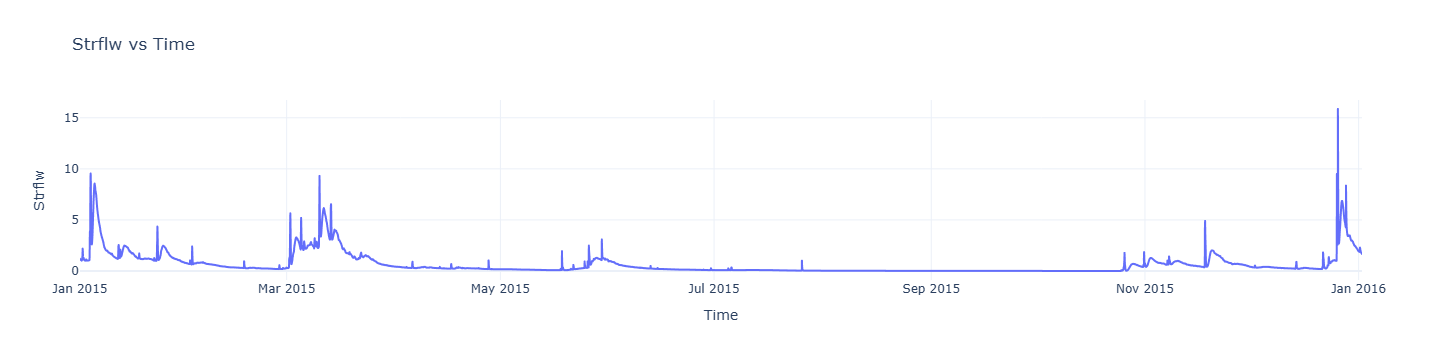

In [197]:
import plotly.express as px
import pandas as pd

df_plot = df_nwm_out.copy()
df_plot.index = pd.to_datetime(df_plot.index, errors="coerce")
df_plot["Strflw"] = pd.to_numeric(df_plot["Strflw"], errors="coerce")
df_plot = df_plot.dropna(subset=["Strflw"]).sort_index()
df_plot = df_plot.reset_index().rename(columns={"index": "Time"})

fig = px.line(
    df_plot,
    x="Time",
    y="Strflw",
    title="Strflw vs Time",
    labels={"Strflw": "Strflw", "Time": "Time"}
 )
fig.update_traces(line=dict(width=2))
fig.update_layout(template="plotly_white")
fig.show()

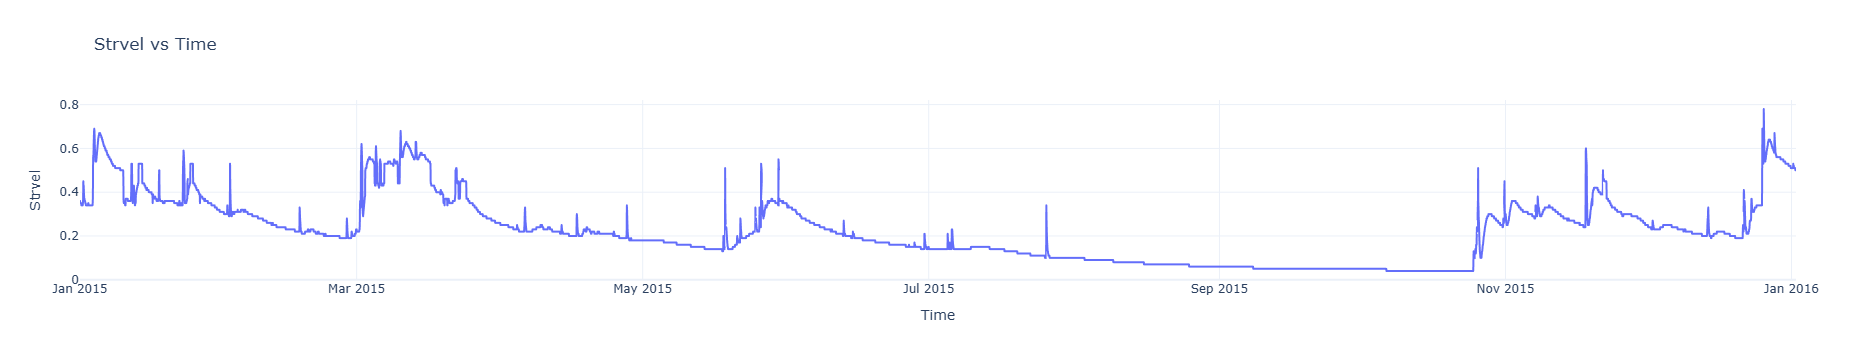

In [21]:
df_plot = df_nwm_out.copy()
df_plot.index = pd.to_datetime(df_plot.index, errors="coerce")
df_plot["Strvel"] = pd.to_numeric(df_plot["Strvel"], errors="coerce")
df_plot = df_plot.dropna(subset=["Strvel"]).sort_index()
df_plot = df_plot.reset_index().rename(columns={"index": "Time"})

fig = px.line(
    df_plot,
    x="Time",
    y="Strvel",
    title="Strvel vs Time",
    labels={"Strvel": "Strvel", "Time": "Time"}
 )
fig.update_traces(line=dict(width=2))
fig.update_layout(template="plotly_white")
fig.show()

In [15]:
import json
json.loads(data)

{'source': 'nwm',
 'dateTimeSpan': {'startDate': '01/01/2015 00:00:00',
  'endDate': '12/31/2015 00:00:00',
  'dateTimeFormat': 'yyyy-MM-dd HH'},
 'geometry': {'description': None,
  'comID': 19121554,
  'hucID': None,
  'stationID': None,
  'point': None,
  'geometryMetadata': {'gaugestation': 'null'},
  'timezone': None},
 'dataValueFormat': 'E3',
 'temporalResolution': 'hourly',
 'timeLocalized': False,
 'units': 'metric',
 'outputFormat': 'json',
 'baseURL': None,
 'inputTimeSeries': None}

In [22]:
nwm_data_request = json.loads(data)

In [25]:
nwm_data_request['dateTimeSpan'].update(endDate= '2016-01-01T00:00:00')

In [26]:
nwm_data_request

{'source': 'nwm',
 'dateTimeSpan': {'startDate': '01/01/2015 00:00:00',
  'endDate': '2016-01-01T00:00:00',
  'dateTimeFormat': 'yyyy-MM-dd HH'},
 'geometry': {'description': None,
  'comID': 19121554,
  'hucID': None,
  'stationID': None,
  'point': None,
  'geometryMetadata': {'gaugestation': 'null'},
  'timezone': None},
 'dataValueFormat': 'E3',
 'temporalResolution': 'hourly',
 'timeLocalized': False,
 'units': 'metric',
 'outputFormat': 'json',
 'baseURL': None,
 'inputTimeSeries': None}

In [34]:
#NWIS Acquistion by gugage number 

In [35]:
import requests

headers = {
    'accept': '*/*',
    'Content-Type': 'application/json-patch+json',
}

data = '{\n  "source": "nwis",\n  "dateTimeSpan": {\n    "startDate": "01/01/2015 00:00:00",\n    "endDate": "12/31/2015 00:00:00",\n    "dateTimeFormat": "yyyy-MM-dd HH"\n  },\n  "geometry": {\n    "description": null,\n    "comID": 0,\n    "hucID": null,\n    "stationID": null,\n    "point": null,\n    "geometryMetadata": {\n      "gaugestation": "02191300"\n    },\n    "timezone": null\n  },\n  "dataValueFormat": "E3",\n  "temporalResolution": "hourly",\n  "timeLocalized": false,\n  "units": "metric",\n  "outputFormat": "json",\n  "baseURL": null,\n  "inputTimeSeries": null\n}'

response = requests.post('https://qed.epa.gov/hms/rest/api/hydrology/streamflow', headers=headers, data=data)

In [36]:
nwis_output = response.json()

In [37]:
nwis_output.keys()

dict_keys(['dataset', 'dataSource', 'metadata', 'data'])

In [38]:
nwis_output['dataset']

'streamflow'

In [39]:
nwis_output['dataSource']

'usgs'

In [40]:
nwis_output['metadata']

{'NWIS_GAGEID': '2191300',
 'NWIS_AGENCY_CD': 'USGS',
 'NWIS_STATION_NM': 'BROAD RIVER ABOVE CARLTON, GA',
 'NWIS_STATE_CD': '13',
 'NWIS_STATE': 'GA',
 'NWIS_DASqMi': '760',
 'NWIS_DASqKm': '1968.4',
 'NWIS_LatSite': '34.0733333',
 'NWIS_LonSite': '-83.0033333',
 'NWIS_Active': '1',
 'NWIS_ActiveDate': '20151006',
 'NWIS_GagesII': 'Non-ref',
 'NWIS_EVENTDATE': '12/4/2014',
 'NWIS_REACHCODE': '3060100000000',
 'NWIS_REACHRESOL': 'Medium',
 'NWIS_FEATUREDET': 'http://waterdata.usgs.gov/nwis/nwisman/?site_no=02191300',
 'NWIS_Measure': '50.81509',
 'NWIS_EventType': 'StreamGage',
 'NWIS_FLComID': '6279431',
 'agency_cd': 'USGS',
 'site_no': '02191300',
 'station_nm': 'BROAD RIVER ABOVE CARLTON, GA',
 'dec_lat_va': '34.07422220',
 'dec_long_va': '-83.00394440',
 'coord_acy_cd': 'S',
 'dec_coord_datum_cd': 'NAD83',
 'huc_cd': '03060104',
 'nwis_metadata_url': 'https://nwis.waterdata.usgs.gov/usa/nwis/uv/?search_site_no=02191300&&20&search_site_no_match_type=exact&group_key=NONE&format=site

In [81]:
import pandas as pd
df_nwis_out = pd.DataFrame.from_dict(nwis_output['data'], orient='index',columns=['Strflw'])
df_nwis_out['Strflw'] = df_nwis_out['Strflw'].astype(float)
df_nwis_out # Now we can use dt for unique time series analysis and convert over to the mm/day from streamflow

,Strflw
2015-01-01 00,21.53
2015-01-01 01,21.39
2015-01-01 02,21.52
2015-01-01 03,21.32
2015-01-01 04,21.15
...,...
2015-12-30 20,314.30
2015-12-30 21,311.80
2015-12-30 22,309.40
2015-12-30 23,301.90


In [70]:
df_nwis_out.keys()

Index(['Strflw'], dtype='object')

In [85]:
df_nwis_out.loc[df_nwis_out.Strflw == -9999]

,Strflw
2015-01-29 09:00:00,-9999.0
2015-01-29 10:00:00,-9999.0
2015-01-29 11:00:00,-9999.0
2015-01-29 12:00:00,-9999.0
2015-01-29 13:00:00,-9999.0
...,...
2015-11-09 15:00:00,-9999.0
2015-11-09 16:00:00,-9999.0
2015-11-09 17:00:00,-9999.0
2015-11-09 18:00:00,-9999.0


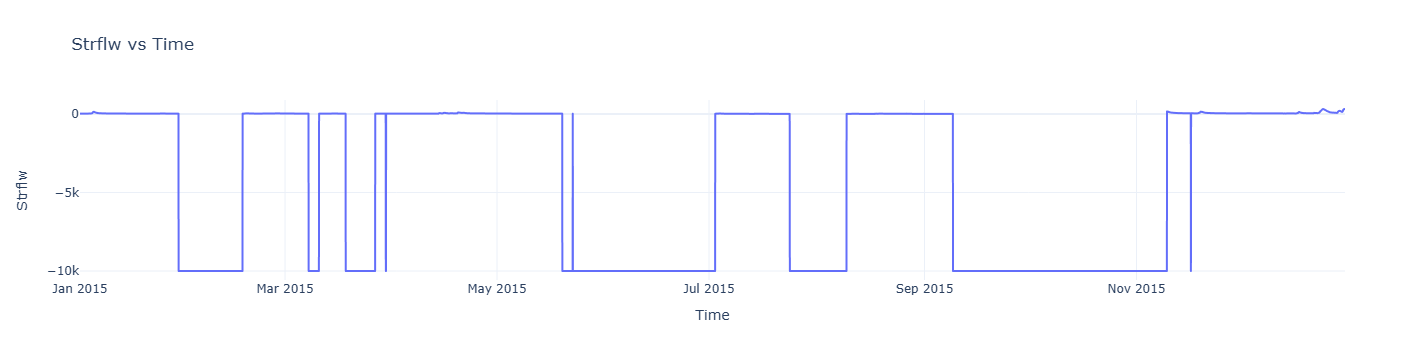

In [84]:
#Before cleaning out -9999
import plotly.express as px
import pandas as pd

df_plot = df_nwis_out
df_plot.index = pd.to_datetime(df_plot.index, errors="coerce")
df_plot["Strflw"] = pd.to_numeric(df_plot["Strflw"], errors="coerce")
df_plot = df_plot.dropna(subset=["Strflw"]).sort_index()
df_plot = df_plot.reset_index().rename(columns={"index": "Time"})

fig = px.line(
    df_plot,
    x="Time",
    y="Strflw",
    title="Strflw vs Time",
    labels={"Strflw": "Strflw", "Time": "Time"}
 )
fig.update_traces(line=dict(width=2))
fig.update_layout(template="plotly_white")
fig.show()

In [89]:
import numpy as np
df_nwis_out.Strflw = df_nwis_out.Strflw.replace(-9999, np.nan) #clean out the data from -9999 values

In [90]:
df_nwis_out.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8737 entries, 2015-01-01 00:00:00 to 2015-12-31 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Strflw  5091 non-null   float64
dtypes: float64(1)
memory usage: 136.5 KB


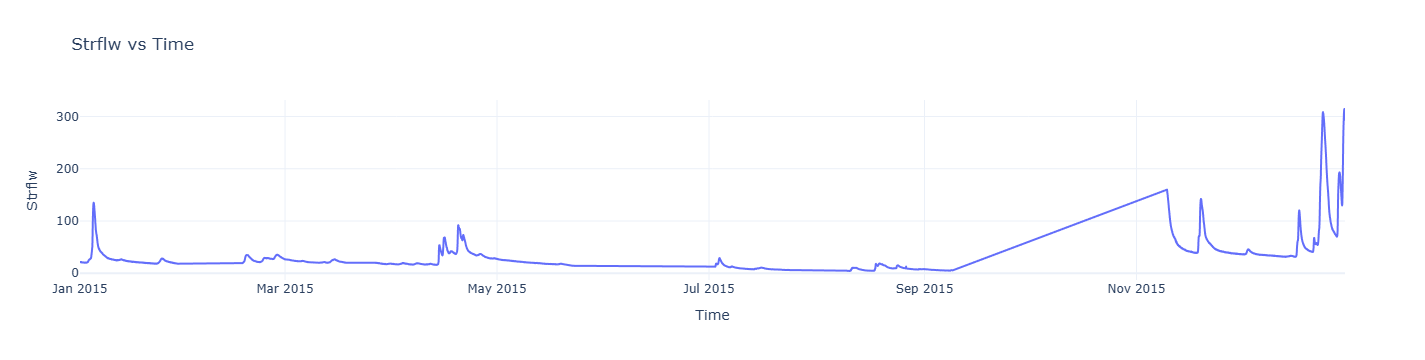

In [91]:
#After Cleaning 
import plotly.express as px
import pandas as pd

df_plot = df_nwis_out
df_plot.index = pd.to_datetime(df_plot.index, errors="coerce")
df_plot["Strflw"] = pd.to_numeric(df_plot["Strflw"], errors="coerce")
df_plot = df_plot.dropna(subset=["Strflw"]).sort_index()
df_plot = df_plot.reset_index().rename(columns={"index": "Time"})

fig = px.line(
    df_plot,
    x="Time",
    y="Strflw",
    title="Strflw vs Time",
    labels={"Strflw": "Strflw", "Time": "Time"}
 )
fig.update_traces(line=dict(width=2))
fig.update_layout(template="plotly_white")
fig.show()

In [150]:
nwm_data_tester='{"source": "nwm", "dateTimeSpan": {"startDate": "2017-01-01T00:00:00", "endDate": "2017-12-31T00:00:00", "dateTimeFormat": "yyyy-MM-dd HH"}, "geometry": {"description": null, "comID": 19121554, "hucID": null, "stationID": null, "point": null, "geometryMetadata": {"gaugestation": null}, "timezone": null}, "dataValueFormat": "E3", "temporalResolution": "daily", "timeLocalized": false, "units": "metric", "outputFormat": "json", "baseURL": null, "inputTimeSeries": null}'

In [151]:
nwm_data_tester

'{"source": "nwm", "dateTimeSpan": {"startDate": "2017-01-01T00:00:00", "endDate": "2017-12-31T00:00:00", "dateTimeFormat": "yyyy-MM-dd HH"}, "geometry": {"description": null, "comID": 19121554, "hucID": null, "stationID": null, "point": null, "geometryMetadata": {"gaugestation": null}, "timezone": null}, "dataValueFormat": "E3", "temporalResolution": "daily", "timeLocalized": false, "units": "metric", "outputFormat": "json", "baseURL": null, "inputTimeSeries": null}'

In [152]:
import requests

headers = {
    'accept': '*/*',
    'Content-Type': 'application/json-patch+json',
}

data = nwm_data_tester

response = requests.post('https://qed.epa.gov/hms/rest/api/hydrology/streamflow', headers=headers, data=data)

In [153]:
nwm_output_ts = response.json()

In [154]:
nwm_output_ts.keys()

dict_keys(['dataset', 'dataSource', 'metadata', 'data'])

In [160]:
nwm_out_2 = nwm_output_ts['data']

In [161]:
import pandas as pd
df_nwm_out_2 = pd.DataFrame.from_dict(nwm_out_2, orient='index',columns=['Strflw', 'Strvel'] )
df_nwm_out_2 # Now we can use dt for unique time series analysis and convert over to the mm/day from streamflow

,Strflw,Strvel
2017-01-01 00,3.000E-002,1.000E-001
2017-01-02 00,1.111E-001,1.502E-001
2017-01-03 00,3.000E-002,1.000E-001
2017-01-04 00,4.000E-002,1.000E-001
2017-01-05 00,4.000E-002,1.097E-001
...,...,...
2017-12-28 00,1.000E-002,6.000E-002
2017-12-29 00,1.000E-002,6.000E-002
2017-12-30 00,1.000E-002,6.000E-002
2017-12-31 00,1.000E-002,6.000E-002


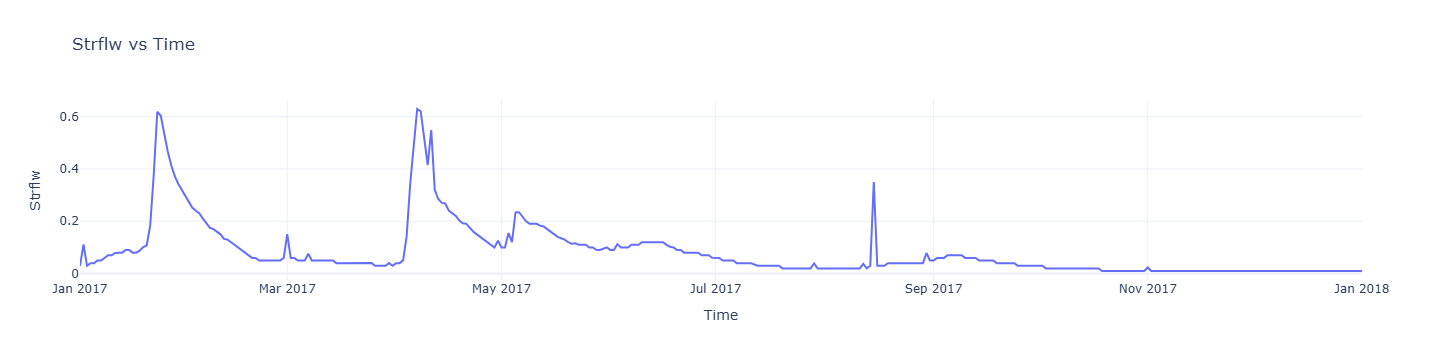

In [162]:
import plotly.express as px
import pandas as pd

df_plot = df_nwm_out_2.copy()
df_plot.index = pd.to_datetime(df_plot.index, errors="coerce")
df_plot["Strflw"] = pd.to_numeric(df_plot["Strflw"], errors="coerce")
df_plot = df_plot.dropna(subset=["Strflw"]).sort_index()
df_plot = df_plot.reset_index().rename(columns={"index": "Time"})

fig = px.line(
    df_plot,
    x="Time",
    y="Strflw",
    title="Strflw vs Time",
    labels={"Strflw": "Strflw", "Time": "Time"}
 )
fig.update_traces(line=dict(width=2))
fig.update_layout(template="plotly_white")
fig.show()

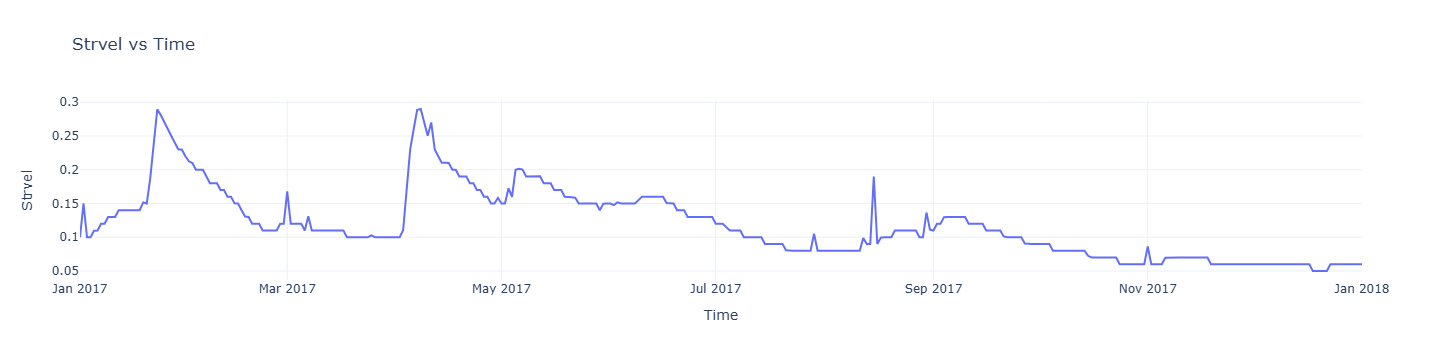

In [163]:
import plotly.express as px
import pandas as pd

df_plot = df_nwm_out_2.copy()
df_plot.index = pd.to_datetime(df_plot.index, errors="coerce")
df_plot["Strvel"] = pd.to_numeric(df_plot["Strvel"], errors="coerce")
df_plot = df_plot.dropna(subset=["Strvel"]).sort_index()
df_plot = df_plot.reset_index().rename(columns={"index": "Time"})

fig = px.line(
    df_plot,
    x="Time",
    y="Strvel",
    title="Strvel vs Time",
    labels={"Strvel": "Strvel", "Time": "Time"}
 )
fig.update_traces(line=dict(width=2))
fig.update_layout(template="plotly_white")
fig.show()